In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
from numpy.random.mtrand import random
np.random.seed(42)

n=200

data = pd.DataFrame({
    "experience": np.random.randint(0, 15, n),
    "education_years": np.random.randint(10, 20, n),
    "age": np.random.randint(18, 60, n),
})

data["salary"] = (
    30000 +
    data["experience"] * 4000 +
    data["education_years"] * 2000 +
    data["age"] * 500 +
    np.random.randn(n) * 10000
)

data.head()

,experience,education_years,age,salary
0,6,14,57,128636.665759
1,3,16,50,103045.828951
2,12,16,26,123900.725870
3,14,13,56,140827.304358
4,10,16,46,122415.822642


In [3]:
len(data)

200

In [7]:
print(data.shape)
print(data.info())
print(data.describe())


(200, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   experience       200 non-null    int64  
 1   education_years  200 non-null    int64  
 2   age              200 non-null    int64  
 3   salary           200 non-null    float64
dtypes: float64(1), int64(3)
memory usage: 6.4 KB
None
       experience  education_years         age         salary
count  200.000000       200.000000  200.000000     200.000000
mean     7.450000        14.030000   39.605000  107755.861354
std      4.320978         2.872343   11.648494   21679.545458
min      0.000000        10.000000   18.000000   58409.084116
25%      4.000000        12.000000   29.750000   90766.357015
50%      7.500000        14.000000   40.500000  108060.262264
75%     11.000000        16.250000   50.000000  124351.144149
max     14.000000        19.000000   59.000000  158758.29957

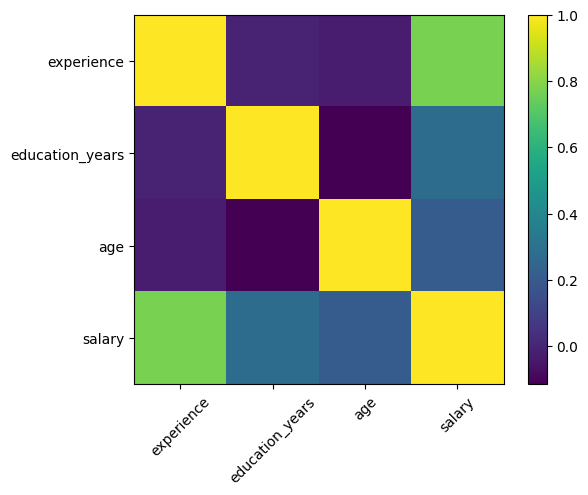

In [8]:
corr = data.corr()

plt.imshow(corr)
plt.colorbar()
plt.xticks(range(len(corr)), corr.columns, rotation=45)
plt.yticks(range(len(corr)), corr.columns)
plt.show()

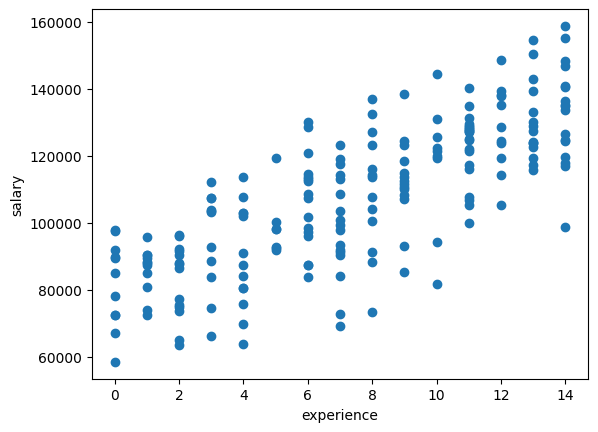

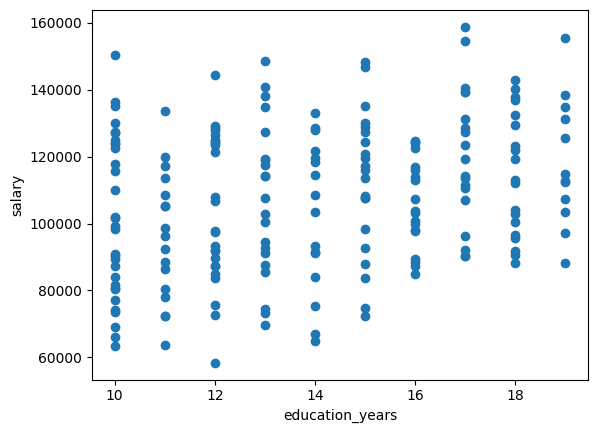

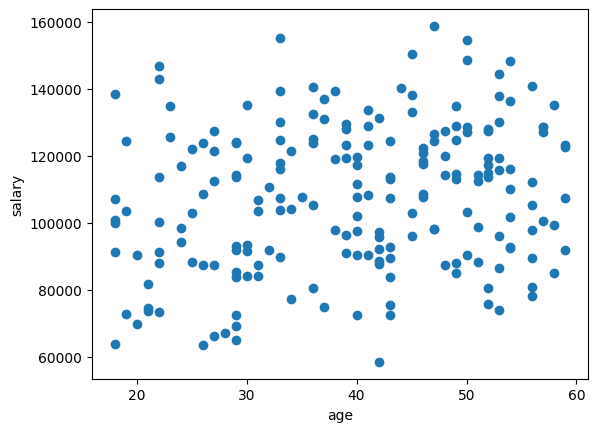

In [9]:
features = ["experience", "education_years", "age"]

for col in features:
  plt.figure()
  plt.scatter(data[col], data["salary"])
  plt.xlabel(col)
  plt.ylabel("salary")
  plt.show()

In [11]:
X = data[["experience", "education_years", "age"]]
y = data["salary"]

In [15]:
X_train, X_test, y_train, y_test =train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [16]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
Salary = slope(b0) + slope(b1) * experience + slope(b2) * education_years + slope(b3) * age

In [19]:
print(model.intercept_)
print(model.coef_)

22474.146903725108
[3839.0894803  2552.72132732  505.74521868]


In [20]:
y_pred = model.predict(X_test)

In [21]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(mse, rmse, r2)

127168161.29586944 11276.886152474424 0.7846665668682562


In [22]:
new_data = pd.DataFrame({
    "experience": [5],
    "education_years": [16],
    "age": [30]
})

print(model.predict(new_data))



[97685.49210274]
